# 3D Print Failure Prediction — Real-World Evaluation
**Cornell Tech MakerLAB Project**

Evaluates the trained LR and NN models against human-labeled real-world print data.
No model retraining — uses the saved weights and preprocessing artifacts from training.

In [17]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import json
import pickle
import matplotlib.pyplot as plt
from src.preprocessing import preprocess_single

DATA_DIR   = "../data/raw/processed"
MODELS_DIR = "../models"
CSV_PATH   = "../data/raw/real_world_data_labeling_sheet.csv"

## 1. Load preprocessing artifacts and saved model weights

In [18]:
with open(f"{DATA_DIR}/scaler_params.json") as f:
    scaler = json.load(f)
with open(f"{DATA_DIR}/feature_cols.json") as f:
    feature_cols = json.load(f)
with open(f"{DATA_DIR}/ohe_cols.json") as f:
    ohe_map = json.load(f)

with open(f"{DATA_DIR}/lr_weights.pkl", "rb") as f:
    lr_weights = pickle.load(f)

import os
nn_weights = None
nn_path = f"{MODELS_DIR}/nn_weights.pkl"
if os.path.exists(nn_path):
    with open(nn_path, "rb") as f:
        nn_weights = pickle.load(f)

print("feature_cols:", feature_cols)
print("LR weights loaded:", lr_weights.keys())
print("NN weights loaded:", nn_weights is not None)

feature_cols: ['nozzle_temperature', 'nozzle_temperature_initial_layer', 'layer_height', 'initial_layer_print_height', 'inner_wall_speed', 'outer_wall_speed', 'bridge_speed', 'fan_max_speed', 'sparse_infill_density', 'bottom_shell_layers', 'top_shell_layers', 'wall_loops', 'retraction_length', 'retraction_speed', 'enable_support', 'filament_type_ABS', 'filament_type_PC', 'filament_type_PETG', 'filament_type_PLA', 'filament_type_TPU']
LR weights loaded: dict_keys(['weights', 'bias'])
NN weights loaded: True


## 2. Load and clean the real-world labeled dataset

In [19]:
FEATURE_COLS_RAW = [
    "nozzle_temperature", "nozzle_temperature_initial_layer",
    "layer_height", "initial_layer_print_height",
    "inner_wall_speed", "outer_wall_speed", "bridge_speed",
    "fan_max_speed", "sparse_infill_density", "bottom_shell_layers",
    "top_shell_layers", "wall_loops", "retraction_length",
    "retraction_speed", "enable_support", "filament_type"
]

df_raw = pd.read_csv(CSV_PATH)
print(f"Raw rows: {len(df_raw)}")

# Drop rows missing the label or any feature
df = df_raw.dropna(subset=["print_outcome"] + [c for c in FEATURE_COLS_RAW if c != "filament_type"]).copy()
df["print_outcome"] = df["print_outcome"].astype(int)

print(f"Usable rows after dropping incomplete: {len(df)}")
print(f"Class distribution — 0 (fail): {(df['print_outcome']==0).sum()} | 1 (success): {(df['print_outcome']==1).sum()}")
df[["video_id", "gcode_filename", "filament_type", "print_outcome"]].head(10)

Raw rows: 58
Usable rows after dropping incomplete: 57
Class distribution — 0 (fail): 22 | 1 (success): 35


,video_id,gcode_filename,filament_type,print_outcome
0,1.0,02.gcode.3mf,PLA,1
1,2.0,2mm_Eevee_Pencil_Holder.gcode.3mf,PLA,1
2,3.0,333.gcode.3mf,PLA,1
3,4.0,A3.gcode.3mf,PLA,0
4,5.0,Activity5.1.2.gcode.3mf,PLA,0
5,6.0,animal-c-A1-minii_plate_1.gcode.3mf,PLA,1
6,7.0,arm.gcode.3mf,PLA,0
7,8.0,arm_rest.gcode.3mf,PLA,1
8,9.0,AS3-V1.gcode.3mf,PLA,1
9,10.0,AS3-V2.gcode.3mf,PLA,1


## 3. Preprocess each row using training artifacts

We reuse the exact same scaler and OHE fitted on the training split — no re-fitting on real-world data.

In [20]:
X_list = []
for _, row in df.iterrows():
    raw = {col: row[col] for col in FEATURE_COLS_RAW}
    X_list.append(preprocess_single(raw, feature_cols, scaler, ohe_map)[0])

X_real = np.vstack(X_list).astype(np.float32)

# Training target: 1=failure, 0=success
# Real-world sheet: 1=success, 0=failure  → invert to align with model
y_real = 1 - df["print_outcome"].values

print("Feature matrix shape:", X_real.shape)
print("Label shape:", y_real.shape)
print("Converted to model convention — 1=failure, 0=success")
print(f"Failures: {(y_real==1).sum()} | Successes: {(y_real==0).sum()}")

Feature matrix shape: (57, 20)
Label shape: (57,)
Converted to model convention — 1=failure, 0=success
Failures: 22 | Successes: 35


## 4. Inference — predict probabilities with both models

In [21]:
def lr_predict_proba(weights, X):
    w = np.array(weights["weights"])
    b = float(weights["bias"])
    z = np.clip(X @ w + b, -500, 500)
    return 1 / (1 + np.exp(-z))


def nn_predict_proba(weights, X):
    a = X.copy()
    n = weights.get("n_layers", 1)
    for i in range(1, n + 1):
        W = np.array(weights[f"W{i}"])
        b = np.array(weights[f"b{i}"])
        a = np.maximum(0, a @ W + b)
    W_out = np.array(weights["W_out"])
    b_out = np.array(weights["b_out"])
    z = np.clip(a @ W_out + b_out, -500, 500)
    return (1 / (1 + np.exp(-z))).ravel()


lr_proba = lr_predict_proba(lr_weights, X_real)
nn_proba = nn_predict_proba(nn_weights, X_real) if nn_weights is not None else None

print("LR proba sample:", lr_proba[:5].round(3))
if nn_proba is not None:
    print("NN proba sample:", nn_proba[:5].round(3))

LR proba sample: [0.488 0.5   0.5   0.505 0.501]
NN proba sample: [0.285 0.359 0.359 0.389 0.473]


## 5. Metrics — Accuracy, Precision, Recall, F1, AUC-ROC

In [22]:
def roc_auc(y_true, y_prob):
    thresholds = np.linspace(0, 1, 201)
    tprs, fprs = [], []
    for t in thresholds:
        p  = (y_prob >= t).astype(int)
        tp = np.sum((p == 1) & (y_true == 1))
        fp = np.sum((p == 1) & (y_true == 0))
        fn = np.sum((p == 0) & (y_true == 1))
        tn = np.sum((p == 0) & (y_true == 0))
        tprs.append(tp / (tp + fn + 1e-12))
        fprs.append(fp / (fp + tn + 1e-12))
    return float(-np.trapezoid(tprs, fprs))


def full_report(y_true, y_proba, label="Model", threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    acc  = (y_pred == y_true).mean()
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    auc  = roc_auc(y_true, y_proba)
    print(f"--- {label} (threshold={threshold}) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"Confusion matrix:\n  TP={tp} FP={fp}\n  FN={fn} TN={tn}")
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc,
                tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn))


lr_threshold = lr_weights.get("threshold", 0.5)
lr_metrics   = full_report(y_real, lr_proba, label="Logistic Regression", threshold=lr_threshold)
print()
if nn_proba is not None:
    nn_threshold = nn_weights.get("threshold", 0.5)
    nn_metrics   = full_report(y_real, nn_proba, label="Neural Network", threshold=nn_threshold)

--- Logistic Regression (threshold=0.5) ---
Accuracy:  0.6316
Precision: 0.5455
Recall:    0.2727
F1:        0.3636
AUC-ROC:   0.5604
Confusion matrix:
  TP=6 FP=5
  FN=16 TN=30

--- Neural Network (threshold=0.39999999999999986) ---
Accuracy:  0.6491
Precision: 0.6250
Recall:    0.2273
F1:        0.3333
AUC-ROC:   0.5312
Confusion matrix:
  TP=5 FP=3
  FN=17 TN=32


## 6. Confusion matrix plots

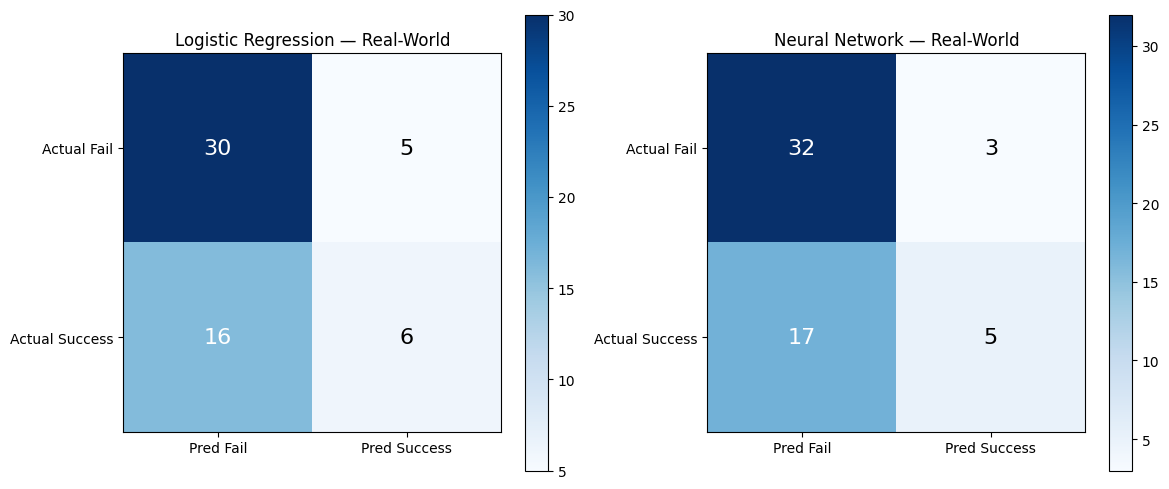

In [23]:
def plot_confusion_matrix(ax, metrics, title):
    cm = np.array([[metrics["tn"], metrics["fp"]],
                   [metrics["fn"], metrics["tp"]]])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Fail", "Pred Success"])
    ax.set_yticklabels(["Actual Fail", "Actual Success"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=16, color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)


n_models = 1 + (nn_proba is not None)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

plot_confusion_matrix(axes[0], lr_metrics, "Logistic Regression — Real-World")
if nn_proba is not None:
    plot_confusion_matrix(axes[1], nn_metrics, "Neural Network — Real-World")

plt.tight_layout()
plt.show()

## 7. Side-by-side metric comparison: real-world vs synthetic test set

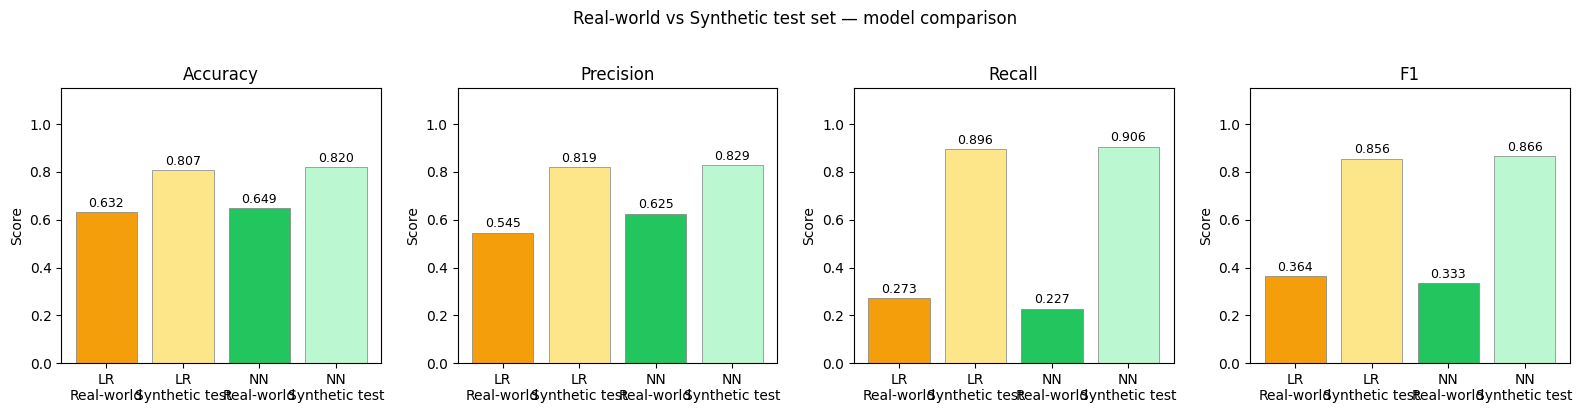

In [24]:
# Load metrics from the synthetic test run (saved by notebook 03/04)
import os
lr_test_metrics = json.load(open(f"{MODELS_DIR}/lr_metrics.json")) if os.path.exists(f"{MODELS_DIR}/lr_metrics.json") else {}
nn_test_metrics = json.load(open(f"{MODELS_DIR}/nn_metrics.json")) if os.path.exists(f"{MODELS_DIR}/nn_metrics.json") else {}

metrics_list = ["accuracy", "precision", "recall", "f1"]

def bar_comparison(ax, metric, lr_real, nn_real, lr_test, nn_test, title):
    labels  = ["LR\nReal-world", "LR\nSynthetic test", "NN\nReal-world", "NN\nSynthetic test"]
    values  = [
        lr_real.get(metric, 0),
        lr_test.get(metric, 0),
        nn_real.get(metric, 0) if nn_proba is not None else 0,
        nn_test.get(metric, 0),
    ]
    colors = ["#f59e0b", "#fde68a", "#22c55e", "#bbf7d0"]
    bars = ax.bar(labels, values, color=colors, edgecolor="gray", linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.set_ylabel("Score")


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, m in zip(axes, metrics_list):
    bar_comparison(ax, m, lr_metrics, nn_metrics if nn_proba is not None else {}, lr_test_metrics, nn_test_metrics, m.capitalize())

plt.suptitle("Real-world vs Synthetic test set — model comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Per-sample prediction breakdown

In [25]:
lr_preds = (lr_proba >= lr_threshold).astype(int)
nn_preds = (nn_proba >= nn_threshold).astype(int) if nn_proba is not None else np.full(len(y_real), np.nan)

results_df = df[["video_id", "gcode_filename", "filament_type", "print_outcome"]].copy().reset_index(drop=True)
results_df["lr_prob"]   = (lr_proba * 100).round(1)
results_df["lr_pred"]   = lr_preds
results_df["lr_correct"] = (lr_preds == y_real)
if nn_proba is not None:
    results_df["nn_prob"]    = (nn_proba * 100).round(1)
    results_df["nn_pred"]    = nn_preds
    results_df["nn_correct"] = (nn_preds == y_real)

# Highlight misclassified rows
def highlight_errors(row):
    color = "background-color: #fee2e2" if not row["lr_correct"] else ""
    return [color] * len(row)

results_df.style.apply(highlight_errors, axis=1)

,video_id,gcode_filename,filament_type,print_outcome,lr_prob,lr_pred,lr_correct,nn_prob,nn_pred,nn_correct
0,1.000000,02.gcode.3mf,PLA,1,48.800000,0,True,28.500000,0,True
1,2.000000,2mm_Eevee_Pencil_Holder.gcode.3mf,PLA,1,50.000000,0,True,35.900000,0,True
2,3.000000,333.gcode.3mf,PLA,1,50.000000,0,True,35.900000,0,True
3,4.000000,A3.gcode.3mf,PLA,0,50.500000,1,True,38.900000,0,False
4,5.000000,Activity5.1.2.gcode.3mf,PLA,0,50.100000,1,True,47.300000,1,True
5,6.000000,animal-c-A1-minii_plate_1.gcode.3mf,PLA,1,50.000000,0,True,35.900000,0,True
6,7.000000,arm.gcode.3mf,PLA,0,48.800000,0,False,28.500000,0,False
7,8.000000,arm_rest.gcode.3mf,PLA,1,50.000000,0,True,35.900000,0,True
8,9.000000,AS3-V1.gcode.3mf,PLA,1,50.000000,0,True,35.900000,0,True
9,10.000000,AS3-V2.gcode.3mf,PLA,1,50.000000,0,True,35.900000,0,True


## 9. Save real-world evaluation results

In [26]:
output = {
    "n_samples":           int(len(y_real)),
    "class_dist":          {"fail": int((y_real == 0).sum()), "success": int((y_real == 1).sum())},
    "logistic_regression": {k: round(float(v), 4) for k, v in lr_metrics.items()},
}
if nn_proba is not None:
    output["neural_network"] = {k: round(float(v), 4) for k, v in nn_metrics.items()}

out_path = f"{MODELS_DIR}/real_world_eval.json"
with open(out_path, "w") as f:
    json.dump(output, f, indent=2)

print(f"Saved → {out_path}")
print(json.dumps(output, indent=2))

Saved → ../models/real_world_eval.json
{
  "n_samples": 57,
  "class_dist": {
    "fail": 35,
    "success": 22
  },
  "logistic_regression": {
    "accuracy": 0.6316,
    "precision": 0.5455,
    "recall": 0.2727,
    "f1": 0.3636,
    "auc": 0.5604,
    "tp": 6.0,
    "fp": 5.0,
    "fn": 16.0,
    "tn": 30.0
  },
  "neural_network": {
    "accuracy": 0.6491,
    "precision": 0.625,
    "recall": 0.2273,
    "f1": 0.3333,
    "auc": 0.5312,
    "tp": 5.0,
    "fp": 3.0,
    "fn": 17.0,
    "tn": 32.0
  }
}
